In [1]:
#Import Kaggle dataset
from google.colab import userdata
import os

os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')


In [2]:
!apt-get install tree
!kaggle datasets download -d ayuraj/asl-dataset
! unzip -q "/content/asl-dataset.zip"

Dataset URL: https://www.kaggle.com/datasets/ayuraj/asl-dataset
License(s): CC0-1.0
  0% 0.00/56.9M [00:00<?, ?B/s]
100% 56.9M/56.9M [00:00<00:00, 1.80GB/s]


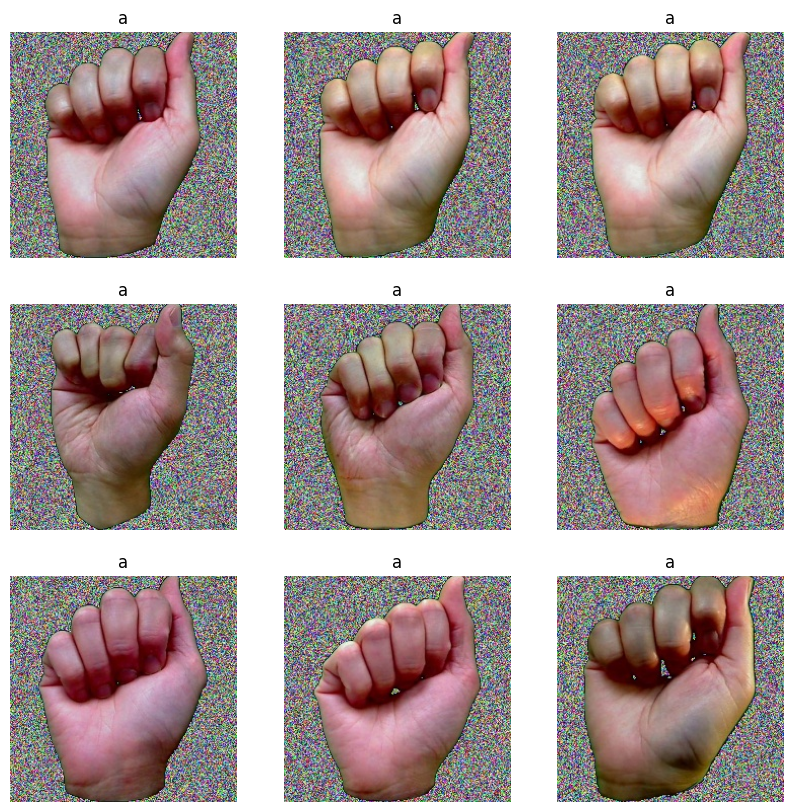

In [32]:
import matplotlib.pyplot as plt
import random

image_dir = "/content/asl_dataset/a"
image_files = [os.path.join(image_dir, f) for f in os.listdir(image_dir) if f.endswith('.jpeg')]

plt.figure(figsize=(10, 10))
for i in range(min(9, len(image_files))):
    img_path = random.choice(image_files)
    img = plt.imread(img_path)
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(os.path.basename(os.path.dirname(img_path)))
    plt.axis('off')

plt.show()

Processing labels: 100%|██████████| 36/36 [00:12<00:00,  2.77it/s]


✅ Done. Processed 2515 images.
📁 Output dataset located at: /content/asl_dataset_with_random_rgb_values


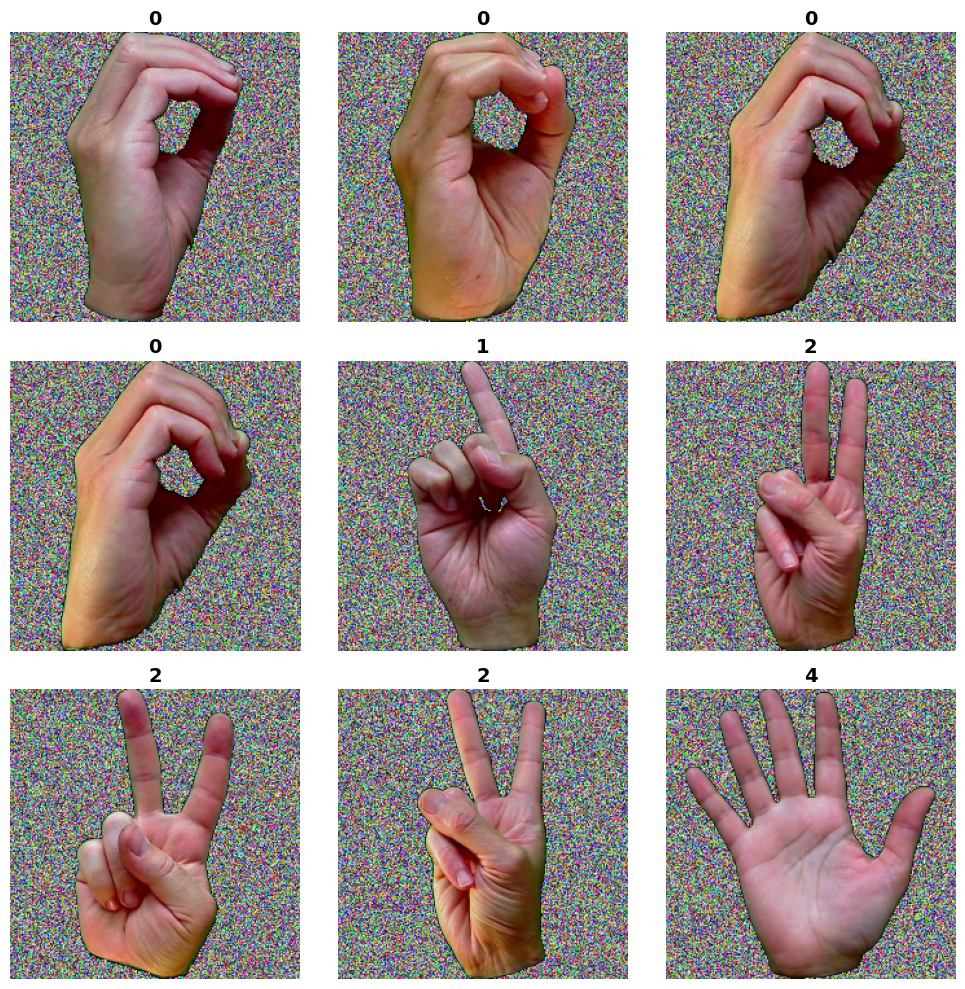

In [48]:
import os
import re
import random
import numpy as np
import cv2
import tqdm
import matplotlib.pyplot as plt

# ---------- CONFIG ----------
in_dir = "/content/asl_dataset"                # original dataset
target_size = (224, 224)                       # resize size
dark_thresh = 15                               # threshold for black mask
show_examples = 9                              # number of modified samples to visualize
# ----------------------------

# Create safe sibling output folder
in_dir_abs = os.path.abspath(in_dir)
parent = os.path.dirname(in_dir_abs)
out_dir_abs = os.path.join(parent, "asl_dataset_with_random_rgb_values")

# Valid label subfolders (a–z, 0–9)
label_names = [
    d for d in sorted(os.listdir(in_dir_abs))
    if os.path.isdir(os.path.join(in_dir_abs, d)) and re.fullmatch(r"[0-9a-z]", d)
]

for lbl in label_names:
    os.makedirs(os.path.join(out_dir_abs, lbl), exist_ok=True)

valid_exts = (".jpg", ".jpeg", ".png")
processed = 0
sample_images = []  # store modified samples for visualization

for lbl in tqdm.tqdm(label_names, desc="Processing labels"):
    in_lbl_dir = os.path.join(in_dir_abs, lbl)
    out_lbl_dir = os.path.join(out_dir_abs, lbl)

    for fname in os.listdir(in_lbl_dir):
        if not fname.lower().endswith(valid_exts):
            continue

        in_path = os.path.join(in_lbl_dir, fname)
        out_path = os.path.join(out_lbl_dir, fname)

        img_bgr = cv2.imread(in_path)
        if img_bgr is None:
            continue

        # Resize and convert to RGB
        img_bgr = cv2.resize(img_bgr, target_size, interpolation=cv2.INTER_AREA)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        # Create mask for dark background
        mask = np.all(img_rgb < [dark_thresh, dark_thresh, dark_thresh], axis=-1)

        # Generate random RGB background
        random_bg = np.random.randint(0, 256, img_rgb.shape, dtype=np.uint8)

        # Apply random background
        modified_rgb = np.where(mask[..., None], random_bg, img_rgb)

        # Save the modified image
        cv2.imwrite(out_path, cv2.cvtColor(modified_rgb, cv2.COLOR_RGB2BGR))
        processed += 1

        # Randomly collect a few modified samples for visualization
        if len(sample_images) < show_examples and random.random() < 0.05:
            sample_images.append((modified_rgb, lbl))

print(f"✅ Done. Processed {processed} images.")
print(f"📁 Output dataset located at: {out_dir_abs}")

# ---------- VISUALIZATION ----------
if sample_images:
    plt.figure(figsize=(10, 10))
    for i, (img, lbl) in enumerate(sample_images[:show_examples]):
        plt.subplot(3, 3, i + 1)
        plt.imshow(img)
        plt.title(lbl, fontsize=14, weight='bold')
        plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No samples selected for visualization.")


In [49]:
import os
import shutil
import re
import tqdm

# ---------- CONFIG ----------
src_dirs = [
    "/content/asl_dataset",
    "/content/asl_dataset_with_random_rgb_values"
]
combined_dir = "/content/asl_dataset_combined"
# ----------------------------

# Create combined output directory safely
os.makedirs(combined_dir, exist_ok=True)

# Determine valid label subfolders (0–9, a–z)
label_pattern = re.compile(r"^[0-9a-z]$")
all_labels = set()

for src in src_dirs:
    for name in os.listdir(src):
        path = os.path.join(src, name)
        if os.path.isdir(path) and label_pattern.match(name):
            all_labels.add(name)

# Create label subfolders in combined dataset
for label in sorted(all_labels):
    os.makedirs(os.path.join(combined_dir, label), exist_ok=True)

# Copy all files from both datasets into combined dataset
for src in src_dirs:
    print(f"📂 Merging from {src}...")
    for label in tqdm.tqdm(sorted(os.listdir(src)), desc=f"Copying from {os.path.basename(src)}"):
        src_label_dir = os.path.join(src, label)
        dst_label_dir = os.path.join(combined_dir, label)

        if not os.path.isdir(src_label_dir) or not label_pattern.match(label):
            continue

        for fname in os.listdir(src_label_dir):
            src_file = os.path.join(src_label_dir, fname)
            dst_file = os.path.join(dst_label_dir, fname)

            # If duplicate filenames exist, rename by prefixing dataset name
            if os.path.exists(dst_file):
                base, ext = os.path.splitext(fname)
                new_name = f"{os.path.basename(src)}_{base}{ext}"
                dst_file = os.path.join(dst_label_dir, new_name)

            try:
                shutil.copy2(src_file, dst_file)
            except Exception as e:
                print(f"⚠️ Skipped {src_file}: {e}")

print("✅ All datasets merged successfully.")
print(f"📁 Combined dataset location: {combined_dir}")


📂 Merging from /content/asl_dataset...


Copying from asl_dataset: 100%|██████████| 36/36 [00:00<00:00, 84.86it/s]


📂 Merging from /content/asl_dataset_with_random_rgb_values...


Copying from asl_dataset_with_random_rgb_values: 100%|██████████| 36/36 [00:01<00:00, 23.06it/s]

✅ All datasets merged successfully.
📁 Combined dataset location: /content/asl_dataset_combined


Found 5030 source images.
Copying originals into output...


100%|██████████| 5030/5030 [00:11<00:00, 454.58it/s]


Output currently has 5030 images.
Need 94970 more images → generating ~19 augs per source.


Augmenting: 100%|██████████| 94970/94970 [17:50<00:00, 88.71it/s]


✅ Created 94970 augmented images.
📁 Final dataset size: 100000 images at /content/asl_dataset_100k


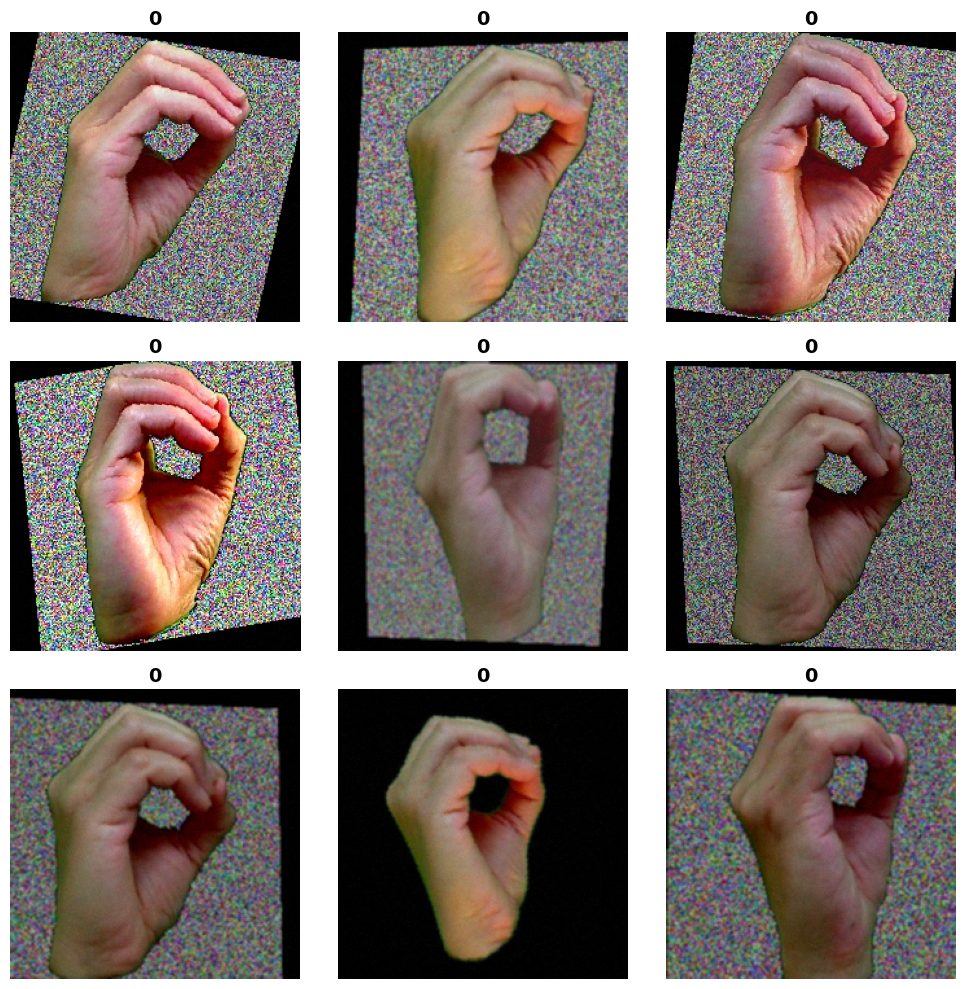

In [53]:
import os, re, math, random, uuid, shutil
from pathlib import Path
from PIL import Image
from tqdm import tqdm

import torch
from torchvision import transforms
import matplotlib.pyplot as plt

# ---------- CONFIG ----------
in_dir = "/content/asl_dataset_combined"
out_dir = "/content/asl_dataset_100k"
target_size = (224, 224)
target_total_images = 100_000
include_originals = True
seed = 42
valid_exts = (".jpg", ".jpeg", ".png")
show_examples = 9  # number of samples to visualize
# ----------------------------

if seed is not None:
    random.seed(seed)
    torch.manual_seed(seed)

in_path  = Path(in_dir).resolve()
out_path = Path(out_dir).resolve()
assert in_path != out_path, "Output must differ from input."
assert not str(out_path).startswith(str(in_path)), "Output directory cannot be inside input."
out_path.mkdir(parents=True, exist_ok=True)

# Label subfolders (0–9, a–z)
label_re = re.compile(r"^[0-9a-z]$")
labels = sorted([d.name for d in in_path.iterdir() if d.is_dir() and label_re.fullmatch(d.name)])
for lbl in labels:
    (out_path / lbl).mkdir(parents=True, exist_ok=True)

# Collect all source images
src_files = []
for lbl in labels:
    for f in (in_path / lbl).iterdir():
        if f.is_file() and f.suffix.lower() in valid_exts:
            src_files.append((lbl, f))
original_total = len(src_files)
print(f"Found {original_total} source images.")

# Copy originals first if requested
current_out_total = 0
if include_originals:
    print("Copying originals into output...")
    for lbl, f in tqdm(src_files):
        try:
            img = Image.open(f).convert("RGB").resize(target_size, Image.BILINEAR)
            dst = out_path / lbl / f.name
            if dst.exists():
                dst = out_path / lbl / f"{f.stem}_orig_{uuid.uuid4().hex[:6]}{f.suffix.lower()}"
            img.save(dst, quality=95)
            current_out_total += 1
        except Exception as e:
            print(f"Skip {f}: {e}")

print(f"Output currently has {current_out_total} images.")

remaining_needed = max(0, target_total_images - current_out_total)
if remaining_needed == 0:
    print("Already reached 100k. Done.")
    raise SystemExit

per_image = math.ceil(remaining_needed / max(1, original_total))
print(f"Need {remaining_needed} more images → generating ~{per_image} augs per source.")

# ----- Augmentation pipeline -----
class AddGaussianNoise:
    def __init__(self, mean=0.0, std=0.02):
        self.mean, self.std = mean, std
    def __call__(self, img):
        noise = torch.randn_like(img) * self.std + self.mean
        return torch.clamp(img + noise, 0.0, 1.0)

augment = transforms.Compose([
    transforms.Resize(target_size, interpolation=Image.BILINEAR),
    transforms.RandomApply([transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.15, hue=0.02)], p=0.8),
    transforms.RandomAffine(degrees=10, translate=(0.05, 0.05), scale=(0.95, 1.05), shear=(-5, 5)),
    transforms.RandomPerspective(distortion_scale=0.25, p=0.4),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),
    transforms.ToTensor(),
    AddGaussianNoise(mean=0.0, std=0.015),
    transforms.ToPILImage()
])

# ----- Augment -----
augmented_samples = []
made = 0
with tqdm(total=remaining_needed, desc="Augmenting") as pbar:
    for lbl, f in src_files:
        try:
            base = Image.open(f).convert("RGB")
        except Exception:
            continue

        for _ in range(per_image):
            if made >= remaining_needed:
                break
            try:
                aug_img = augment(base)
                new_name = f"{f.stem}_aug_{uuid.uuid4().hex[:8]}.jpg"
                out_file = out_path / lbl / new_name
                aug_img.save(out_file, quality=95)
                made += 1
                pbar.update(1)

                # Randomly store for preview
                if len(augmented_samples) < show_examples and random.random() < 0.02:
                    augmented_samples.append((aug_img, lbl))
            except Exception:
                pass
        if made >= remaining_needed:
            break

final_count = current_out_total + made
print(f"✅ Created {made} augmented images.")
print(f"📁 Final dataset size: {final_count} images at {out_path}")

# ---------- VISUALIZATION ----------
if augmented_samples:
    plt.figure(figsize=(10, 10))
    for i, (img, lbl) in enumerate(augmented_samples[:show_examples]):
        plt.subplot(3, 3, i + 1)
        plt.imshow(img)
        plt.title(lbl, fontsize=14, weight="bold")
        plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No samples collected for visualization.")
